In [44]:
## feature scaling

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import matplotlib.pylab as pltlab
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import FunctionTransformer

In [46]:
data = pd.read_csv('../data/loan_data.csv')
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


In [47]:
data.isnull().sum()

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          0
dtype: int64

In [48]:
data["Annual_Income"].fillna(data["Annual_Income"].mean(),inplace=True)

KeyError: 'Annual_Income'

In [ ]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           0
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64

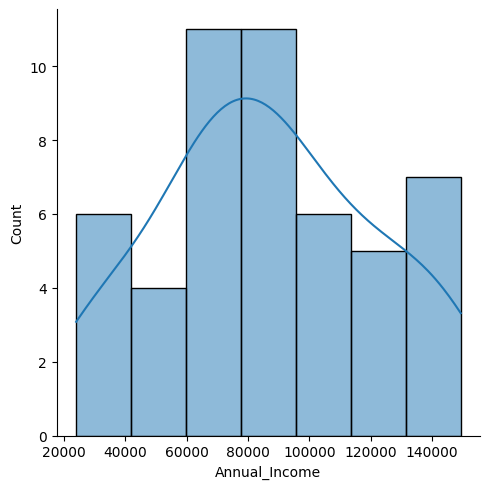

In [ ]:
sns.displot(data['Annual_Income'],kde=True)
plt.show()

In [ ]:
data.describe()

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000


In [ ]:
ss = StandardScaler()
ss.fit(data[['Annual_Income']])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
data['Annual_Income_ss'] = pd.DataFrame(ss.transform(data[['Annual_Income']]), columns=['x'])

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Urban,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,Rural,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,Rural,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901


In [ ]:
data.describe()
data.columns = data.columns.str.strip()


,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance,Annual_Income_ss
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,5.000000e+01
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628,-1.887379e-16
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464,1.010153e+00
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000,-1.788489e+00
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000,-6.233664e-01
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000,0.000000e+00
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000,7.683652e-01
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000,1.821923e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\3247783563.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22916\3247783563.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income_ss'])


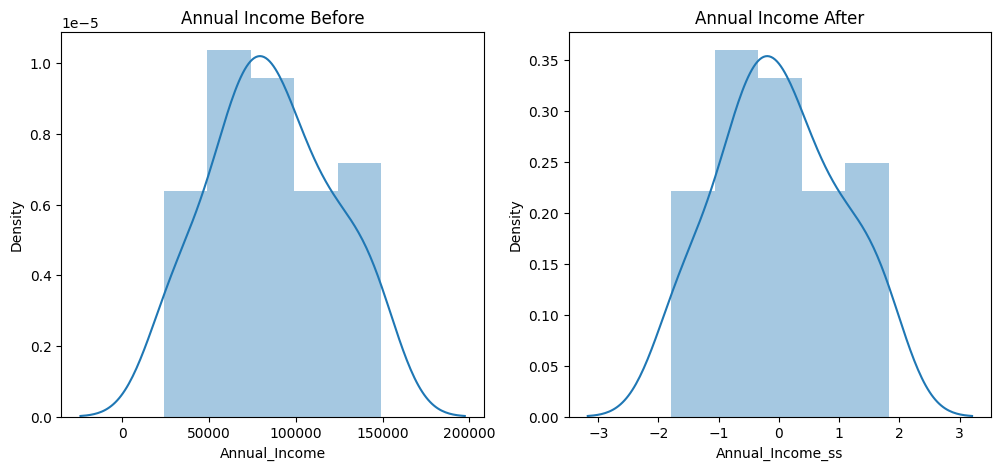

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Annual Income Before')
sns.distplot(data['Annual_Income'])
plt.subplot(1,2,2)
plt.title('Annual Income After')
sns.distplot(data['Annual_Income_ss'])
plt.show()

In [ ]:
data.describe()

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance,Annual_Income_ss
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,5.000000e+01
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628,-1.887379e-16
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464,1.010153e+00
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000,-1.788489e+00
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000,-6.233664e-01
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000,0.000000e+00
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000,7.683652e-01
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000,1.821923e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\2833962190.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])


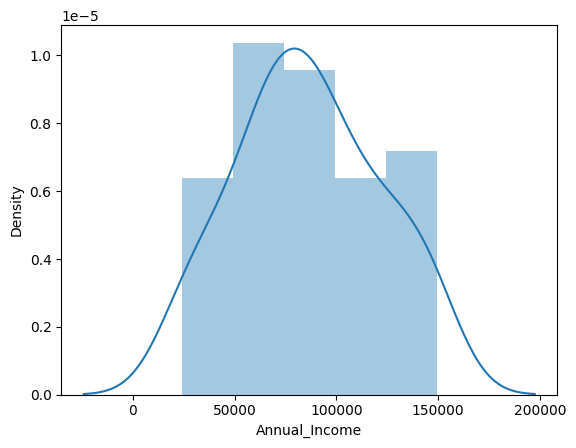

In [ ]:
sns.distplot(data['Annual_Income'])
plt.show()

In [ ]:
ms = MinMaxScaler()
ms.fit(data[['Annual_Income']])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [ ]:
data['Annual_Income_min'] = ms.transform(data[['Annual_Income']])

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss,Annual_Income_min
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934,0.974521
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081,0.456017
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764,0.368026
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844,0.864259
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901,0.719694


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\97496108.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22916\97496108.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income_min'])


<Axes: title={'center': 'after'}, xlabel='Annual_Income_min', ylabel='Density'>

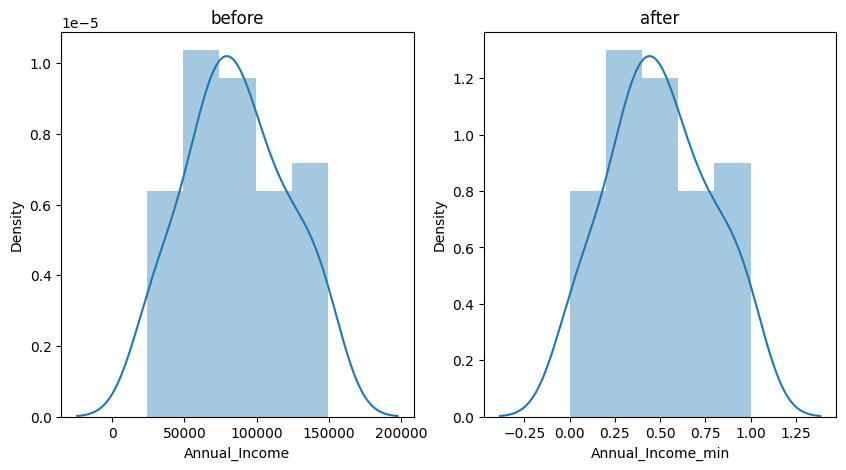

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("before")
sns.distplot(data['Annual_Income'])

plt.subplot(1,2,2)
plt.title("after")
sns.distplot(data['Annual_Income_min'])

In [ ]:
new_data = {"name":["a","b","c","d","e","a","c"], "eng":[5,3,2,4,6,5,3],'hindi':[2,3,4,5,3,2,4]}

In [ ]:
df = pd.DataFrame(new_data)
df

,name,eng,hindi
0,a,5,2
1,b,3,3
2,c,2,4
3,d,4,5
4,e,6,3
5,a,5,2
6,c,3,4


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df

,name,eng,hindi
0,a,5,2
1,b,3,3
2,c,2,4
3,d,4,5
4,e,6,3
6,c,3,4


In [ ]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
dtype: bool

In [ ]:
data.shape

(50, 22)

In [ ]:
data.drop_duplicates(inplace=True)
data.shape

(50, 22)

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss,Annual_Income_min
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934,0.974521
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081,0.456017
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764,0.368026
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844,0.864259
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901,0.719694


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Loan_ID                50 non-null     object
 1    Customer_Age          50 non-null     object
 2    Gender                50 non-null     object
 3    Marital_Status        50 non-null     object
 4    Dependents            50 non-null     object
 5    Education_Level       50 non-null     object
 6    Employment_Type       50 non-null     object
 7    Annual_Income         50 non-null     object
 8    Credit_Score          50 non-null     object
 9    Loan_Amount           50 non-null     object
 10   Loan_Term_Months      50 non-null     object
 11   Property_Area         50 non-null     object
 12   Existing_Loan         50 non-null     object
 13   Loan_Approval_Status  50 non-null     object
 14   Application_Date      50 non-null     object
 15   Last_Payment_Date     50

In [ ]:
data.isnull().sum()

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          0
dtype: int64

In [ ]:
data[' Dependents'].value_counts()
# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()


In [ ]:
# Replace empty strings with NaN
data['Dependents'].replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Fill missing values with mode
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)

# Convert to numeric


C:\Users\HP\AppData\Local\Temp\ipykernel_12892\2333858441.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Dependents'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12892\2333858441.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [ ]:
data['Dependents'].value_counts()

Dependents
3.0    17
2.0     8
0.0     8
4.0     8
1.0     6
9.0     1
6.0     1
3+      1
Name: count, dtype: int64

In [ ]:
data['Dependents'].replace('        3+', '3.0',inplace=True)

In [ ]:
data['Dependents'].value_counts()


Dependents
        3.0    17
        2.0     8
        0.0     8
        4.0     8
        1.0     6
        9.0     1
        6.0     1
3.0             1
Name: count, dtype: int64

In [ ]:
data.head(50)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,3.0,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone
5,L1005,41.0,Female,Single,0.0,Postgraduate,Unemployed,,316.0,33312.0,12.0,Urban,No,Rejected,,2025-05-31,7.51,39.0,19384.0,Phone
6,L1006,59.0,Male,,3.0,Graduate,Self-employed,,471.0,27677.0,60.0,Rural,Yes,Approved,2025-03-13,2025-11-18,,48.0,33606.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,Urban,No,Approved,2025-02-22,2025-11-13,10.72,,10860.0,
8,L1008,43.0,Female,Single,3.0,,,139181.0,457.0,,60.0,,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,,47675.0,36.0,Semiurban,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,


In [ ]:
data['Dependents'] = data['Dependents'].astype("float64")


ValueError: could not convert string to float: '           '

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Loan_ID                50 non-null     object
 1    Customer_Age          50 non-null     object
 2    Gender                50 non-null     object
 3    Marital_Status        50 non-null     object
 4    Dependents            50 non-null     object
 5    Education_Level       50 non-null     object
 6    Employment_Type       50 non-null     object
 7    Annual_Income         50 non-null     object
 8    Credit_Score          50 non-null     object
 9    Loan_Amount           50 non-null     object
 10   Loan_Term_Months      50 non-null     object
 11   Property_Area         50 non-null     object
 12   Existing_Loan         50 non-null     object
 13   Loan_Approval_Status  50 non-null     object
 14   Application_Date      50 non-null     object
 15   Last_Payment_Date     50

In [ ]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            0
Gender                  0
Marital_Status          0
Dependents              0
Education_Level         0
Employment_Type         0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Loan_Term_Months        0
Property_Area           0
Existing_Loan           0
Loan_Approval_Status    0
Application_Date        0
Last_Payment_Date       0
Interest_Rate           0
Number_of_Payments      0
Account_Balance         0
Contact_Method          0
dtype: int64

In [ ]:
## feature scaling

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import matplotlib.pylab as pltlab
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
data = pd.read_csv('../data/loan_data.csv')
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone


In [ ]:
data.isnull().sum()

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          0
dtype: int64

In [ ]:
data["Annual_Income"].fillna(data["Annual_Income"].mean(),inplace=True)

KeyError: 'Annual_Income'

In [ ]:
data.isnull().sum()

Loan_ID                 0
Customer_Age            7
Gender                  7
Marital_Status          7
Dependents              7
Education_Level         7
Employment_Type         7
Annual_Income           0
Credit_Score            7
Loan_Amount             7
Loan_Term_Months        7
Property_Area           7
Existing_Loan           7
Loan_Approval_Status    7
Application_Date        7
Last_Payment_Date       7
Interest_Rate           7
Number_of_Payments      7
Account_Balance         7
Contact_Method          7
dtype: int64

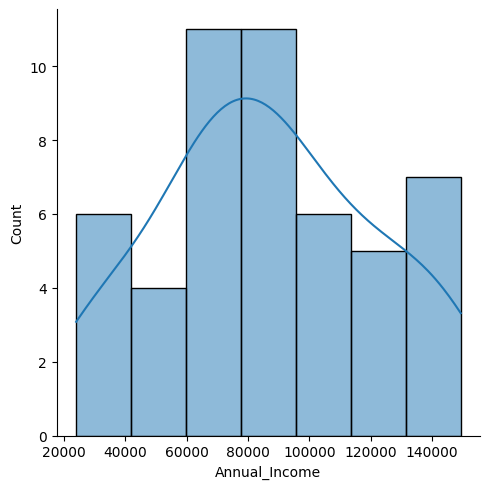

In [ ]:
sns.displot(data['Annual_Income'],kde=True)
plt.show()

In [ ]:
data.describe()

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000


In [ ]:
ss = StandardScaler()
ss.fit(data[['Annual_Income']])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
data['Annual_Income_ss'] = pd.DataFrame(ss.transform(data[['Annual_Income']]), columns=['x'])

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Urban,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,Urban,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,Rural,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,Rural,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901


In [ ]:
data.describe()
data.columns = data.columns.str.strip()


,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance,Annual_Income_ss
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,5.000000e+01
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628,-1.887379e-16
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464,1.010153e+00
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000,-1.788489e+00
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000,-6.233664e-01
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000,0.000000e+00
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000,7.683652e-01
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000,1.821923e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\3247783563.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22916\3247783563.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income_ss'])


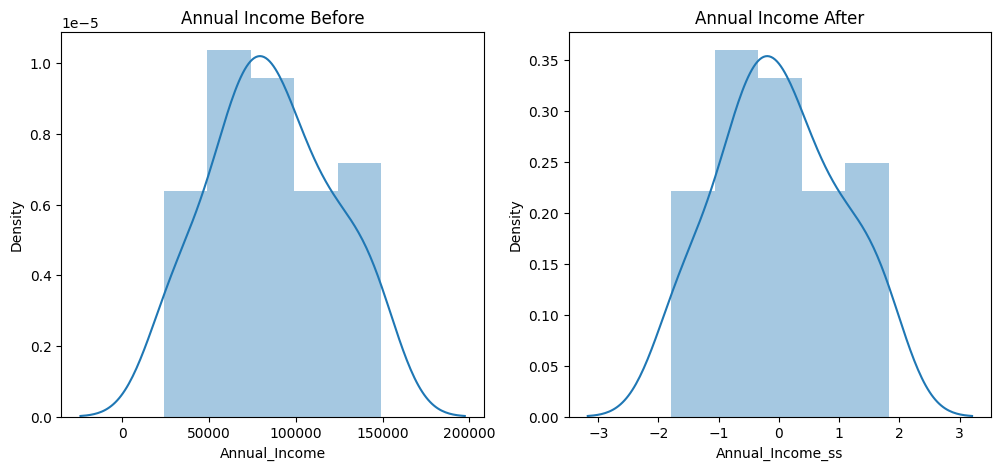

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Annual Income Before')
sns.distplot(data['Annual_Income'])
plt.subplot(1,2,2)
plt.title('Annual Income After')
sns.distplot(data['Annual_Income_ss'])
plt.show()

In [ ]:
data.describe()

,Customer_Age,Dependents,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Number_of_Payments,Account_Balance,Annual_Income_ss
count,43.000000,43.000000,50.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,5.000000e+01
mean,43.488372,2.162791,86066.744186,558.930233,26208.209302,37.395349,8.946977,36.302326,25792.511628,-1.887379e-16
std,12.075895,1.413038,35063.119390,168.560205,11564.728942,17.800668,2.459198,13.871064,14247.150464,1.010153e+00
min,22.000000,0.000000,23987.000000,316.000000,6150.000000,12.000000,4.590000,12.000000,1404.000000,-1.788489e+00
25%,35.500000,1.000000,64429.250000,421.000000,17043.500000,24.000000,7.145000,24.000000,14109.500000,-6.233664e-01
50%,44.000000,2.000000,86066.744186,545.000000,26606.000000,36.000000,8.970000,38.000000,24574.000000,0.000000e+00
75%,51.500000,3.000000,112737.250000,695.500000,35519.000000,54.000000,11.225000,45.500000,39250.500000,7.683652e-01
max,64.000000,4.000000,149307.000000,846.000000,47675.000000,60.000000,12.440000,60.000000,49212.000000,1.821923e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\2833962190.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])


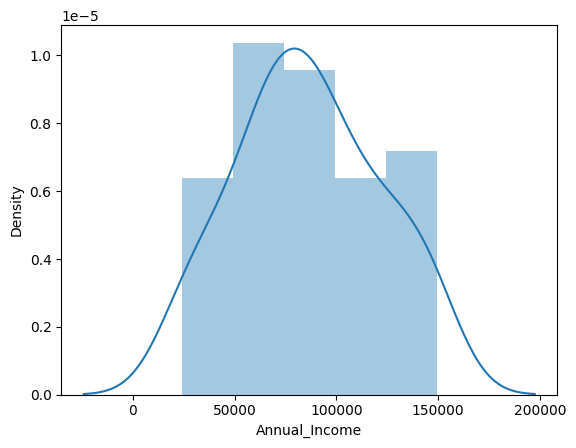

In [ ]:
sns.distplot(data['Annual_Income'])
plt.show()

In [ ]:
ms = MinMaxScaler()
ms.fit(data[['Annual_Income']])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [ ]:
data['Annual_Income_min'] = ms.transform(data[['Annual_Income']])

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss,Annual_Income_min
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934,0.974521
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081,0.456017
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764,0.368026
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844,0.864259
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901,0.719694


C:\Users\HP\AppData\Local\Temp\ipykernel_22916\97496108.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22916\97496108.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income_min'])


<Axes: title={'center': 'after'}, xlabel='Annual_Income_min', ylabel='Density'>

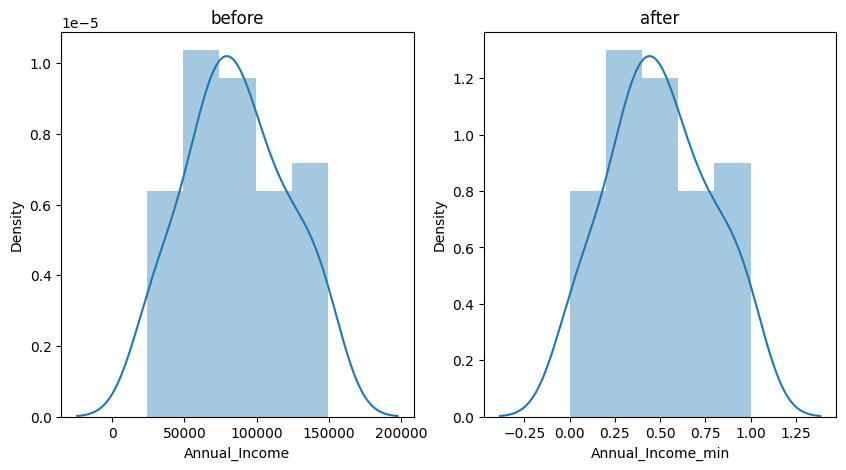

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("before")
sns.distplot(data['Annual_Income'])

plt.subplot(1,2,2)
plt.title("after")
sns.distplot(data['Annual_Income_min'])

In [ ]:
new_data = {"name":["a","b","c","d","e","a","c"], "eng":[5,3,2,4,6,5,3],'hindi':[2,3,4,5,3,2,4]}

In [ ]:
df = pd.DataFrame(new_data)
df

,name,eng,hindi
0,a,5,2
1,b,3,3
2,c,2,4
3,d,4,5
4,e,6,3
5,a,5,2
6,c,3,4


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df

,name,eng,hindi
0,a,5,2
1,b,3,3
2,c,2,4
3,d,4,5
4,e,6,3
6,c,3,4


In [ ]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
dtype: bool

In [ ]:
data.shape

(50, 22)

In [ ]:
data.drop_duplicates(inplace=True)
data.shape

(50, 22)

In [ ]:
data.head()

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,...,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method,Annual_Income_ss,Annual_Income_min
0,L1000,59.0,Male,NaN,1.0,High School,NaN,146114.0,815.0,18403.0,...,Yes,NaN,2025-11-24,2025-10-02,NaN,NaN,1404.0,NaN,1.729934,0.974521
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,...,No,Approved,2025-02-27,2025-03-05,11.00,NaN,41943.0,Branch,-0.142081,0.456017
2,L1002,35.0,Male,Single,3.0,High School,NaN,70108.0,491.0,18121.0,...,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,NaN,Branch,-0.459764,0.368026
3,L1003,63.0,Female,Divorced,NaN,Graduate,Salaried,132296.0,348.0,15966.0,...,NaN,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch,1.331844,0.864259
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,NaN,38621.0,...,No,NaN,2025-05-06,NaN,10.53,39.0,13763.0,Phone,0.809901,0.719694


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Loan_ID                50 non-null     object
 1    Customer_Age          50 non-null     object
 2    Gender                50 non-null     object
 3    Marital_Status        50 non-null     object
 4    Dependents            50 non-null     object
 5    Education_Level       50 non-null     object
 6    Employment_Type       50 non-null     object
 7    Annual_Income         50 non-null     object
 8    Credit_Score          50 non-null     object
 9    Loan_Amount           50 non-null     object
 10   Loan_Term_Months      50 non-null     object
 11   Property_Area         50 non-null     object
 12   Existing_Loan         50 non-null     object
 13   Loan_Approval_Status  50 non-null     object
 14   Application_Date      50 non-null     object
 15   Last_Payment_Date     50

In [ ]:
data.isnull().sum()

Loan_ID                  0
 Customer_Age            0
 Gender                  0
 Marital_Status          0
 Dependents              0
 Education_Level         0
 Employment_Type         0
 Annual_Income           0
 Credit_Score            0
 Loan_Amount             0
 Loan_Term_Months        0
 Property_Area           0
 Existing_Loan           0
 Loan_Approval_Status    0
 Application_Date        0
 Last_Payment_Date       0
 Interest_Rate           0
 Number_of_Payments      0
 Account_Balance         0
 Contact_Method          0
dtype: int64

In [ ]:
data[' Dependents'].value_counts()
# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()


In [ ]:
# Replace empty strings with NaN
data['Dependents'].replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Fill missing values with mode
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)

# Convert to numeric


C:\Users\HP\AppData\Local\Temp\ipykernel_12892\2333858441.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Dependents'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12892\2333858441.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [ ]:
data['Dependents'].value_counts()

Dependents
3.0    17
2.0     8
0.0     8
4.0     8
1.0     6
9.0     1
6.0     1
3+      1
Name: count, dtype: int64

In [ ]:
data['Dependents'].replace('        3+', '3.0',inplace=True)

In [ ]:
data['Dependents'].value_counts()


Dependents
        3.0    17
        2.0     8
        0.0     8
        4.0     8
        1.0     6
        9.0     1
        6.0     1
3.0             1
Name: count, dtype: int64

In [ ]:
data.head(50)

,Loan_ID,Customer_Age,Gender,Marital_Status,Dependents,Education_Level,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loan,Loan_Approval_Status,Application_Date,Last_Payment_Date,Interest_Rate,Number_of_Payments,Account_Balance,Contact_Method
0,L1000,59.0,Male,,1.0,High School,,146114.0,815.0,18403.0,12.0,Urban,Yes,,2025-11-24,2025-10-02,,,1404.0,
1,L1001,49.0,Female,Single,1.0,Graduate,Unemployed,81135.0,846.0,37097.0,24.0,Urban,No,Approved,2025-02-27,2025-03-05,11.0,,41943.0,Branch
2,L1002,35.0,Male,Single,3.0,High School,,70108.0,491.0,18121.0,12.0,Urban,No,Rejected,2025-01-13,2025-07-13,12.08,37.0,,Branch
3,L1003,63.0,Female,Divorced,,Graduate,Salaried,132296.0,348.0,15966.0,,Rural,,Approved,2025-05-21,2025-02-10,12.39,19.0,30189.0,Branch
4,L1004,28.0,Male,Single,2.0,Graduate,Salaried,114179.0,,38621.0,60.0,Rural,No,,2025-05-06,,10.53,39.0,13763.0,Phone
7,L1007,39.0,Male,Divorced,4.0,Postgraduate,Salaried,43328.0,519.0,36289.0,60.0,Urban,No,Approved,2025-02-22,2025-11-13,10.72,,10860.0,
8,L1008,43.0,Female,Single,3.0,,,139181.0,457.0,,60.0,,Yes,Approved,2025-12-13,2025-07-05,8.97,47.0,39757.0,Phone
9,L1009,31.0,Male,Single,4.0,High School,Salaried,111412.0,,47675.0,36.0,Semiurban,Yes,Approved,2025-10-07,2025-10-23,7.89,38.0,16106.0,
10,L1010,31.0,,Divorced,4.0,High School,Salaried,106831.0,345.0,9777.0,48.0,Rural,Yes,Rejected,2025-02-14,2025-04-09,11.75,28.0,24574.0,Phone
11,L1011,44.0,Female,Divorced,2.0,,Self-employed,23987.0,,34749.0,24.0,Urban,Yes,Rejected,2025-10-30,2025-12-27,5.39,20.0,24524.0,Branch


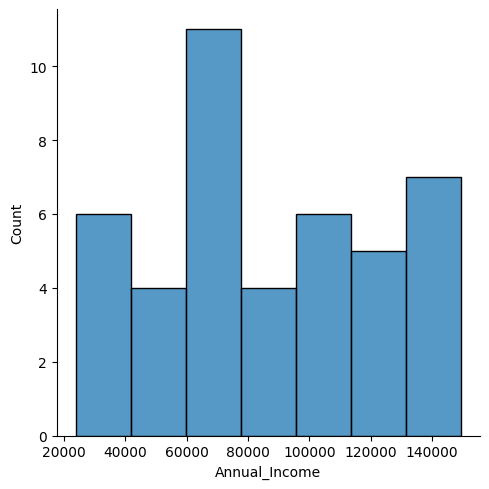

In [ ]:
sns.displot(data['Annual_Income'])
pltlab.show()

In [ ]:
# Strip extra spaces first
data.columns = data.columns.str.strip()
data['Annual_Income'] = pd.to_numeric(data['Annual_Income'], errors='coerce')

# Check dtype
print(data['Annual_Income'].dtype)

# Ab IQR nikal sakte ho
q1 = data['Annual_Income'].quantile(0.25)
q3 = data['Annual_Income'].quantile(0.75)
iqr = q3 - q1
print(q1, q3, iqr)


float64
60791.0 114419.5 53628.5


In [65]:
min_r = q1-(1.5*iqr)
max_r= q3+(1.5*iqr)
min_r,max_r

(np.float64(-19651.75), np.float64(194862.25))

In [66]:
# data= data[data["Annual_Income"]<=max_r]

In [67]:
ft = FunctionTransformer(func=np.log1p)

In [68]:
ft.fit(data[[" Annual_Income"]])
data[' Annual_Income'] = pd.to_numeric(data[' Annual_Income'], errors='coerce')


In [71]:
data[' Annual_Income'].fillna(data[' Annual_Income'].mean(), inplace=True)

data['Annual_Income_log'] =  ft.transform(data[[" Annual_Income"]])

C:\Users\HP\AppData\Local\Temp\ipykernel_9368\4079908160.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[' Annual_Income'].fillna(data[' Annual_Income'].mean(), inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_9368\2401752929.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[' Annual_Income'])
C:\Users\HP\AppData\Local\Temp\ipykernel_9368\2401752929.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Annual_Income_log'])


<Axes: title={'center': 'after'}, xlabel='Annual_Income_log', ylabel='Density'>

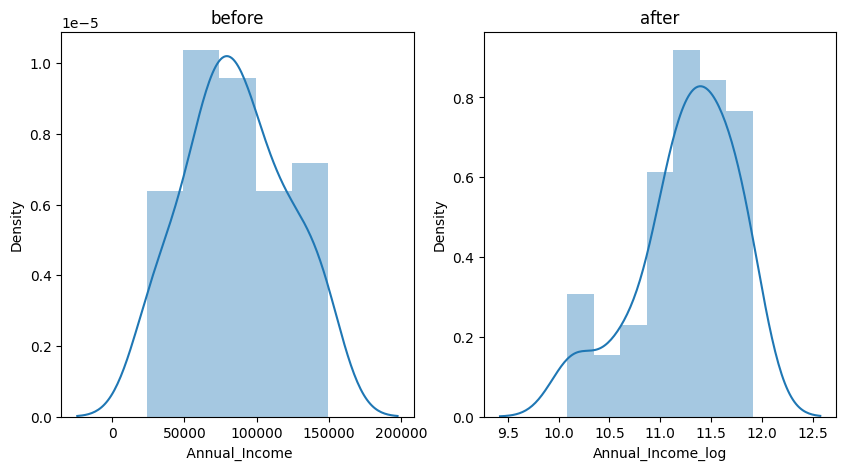

In [73]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("before")
sns.distplot(data[' Annual_Income'])

plt.subplot(1,2,2)
plt.title("after")
sns.distplot(data['Annual_Income_log'])